# 📈 IIT Guwahati CAC — Time Series Analysis 2026 Capstone
### Virtual Portfolio ₹10,00,000 | NSE Stocks | ARIMA · Prophet · XGBoost · LSTM · Ensemble
---

## Section 0 — Setup & Requirements

### `requirements.txt`
```
yfinance>=0.2.36
pandas>=2.0
numpy>=1.24
matplotlib>=3.7
seaborn>=0.12
scikit-learn>=1.3
xgboost>=2.0
prophet>=1.1.5
tensorflow>=2.13
scipy>=1.11
statsmodels>=0.14
arch>=6.3
tqdm>=4.65
```

In [3]:
# # Install all required libraries
# import subprocess, sys
# pkgs = [
#     "yfinance>=0.2.36","pandas>=2.0","numpy>=1.24",
#     "matplotlib>=3.7","seaborn>=0.12","scikit-learn>=1.3",
#     "xgboost>=2.0","prophet>=1.1.5","tensorflow>=2.13",
#     "scipy>=1.11","statsmodels>=0.14","arch>=6.3","tqdm>=4.65"
# ]
# subprocess.check_call([sys.executable,"-m","pip","install","--quiet"]+pkgs)
# print("✅ All packages installed")

In [4]:
# ── Core imports ────────────────────────────────────────────────────────────
import warnings, os, random
warnings.filterwarnings("ignore")
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"

import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from tqdm import tqdm

# ML / Stats
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.seasonal import STL

# XGBoost
from xgboost import XGBRegressor

# Prophet
from prophet import Prophet

# TensorFlow / Keras
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# SciPy optimizer
from scipy.optimize import minimize

# ARCH / GARCH
from arch import arch_model

# ── Global seeds ─────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

# ── Plot style ────────────────────────────────────────────────────────────────
plt.style.use("dark_background")
sns.set_palette("husl")
FIGDIR = "figures"; os.makedirs(FIGDIR, exist_ok=True)

print("✅ Imports OK")

Importing plotly failed. Interactive plots will not work.


✅ Imports OK


In [5]:
import datetime
# ── GLOBAL CONSTANTS ──────────────────────────────────────────────────────────
CAPITAL      = 1_000_000          # ₹10,00,000
START_DATE   = "2021-01-01"
END_DATE = datetime.date.today().strftime("%Y-%m-%d")   # auto = today
TRAIN_END    = "2025-06-30"
TEST_START   = "2025-07-01"
INTERVAL     = "1d"
SEQ_LEN      = 20                 # LSTM look-back window
FORECAST_DAYS = 2                 # Days to forecast for StockGro

STOCKS = {
    "VEDL.NS": "Metals & Mining",
    "TEXRAIL.NS": "Engineering/Infra",
    "ADANIENT.NS": "Conglomerate",
    "DIAMINESQ.NS": "Chemicals",
    "BALAMINES.NS": "Chemicals",
    "AURIONPRO.NS": "IT",
    "FOSECOIND.NS": "Chemicals",
    "JINDRILL.NS": "Energy"
}
TICKERS = list(STOCKS.keys())
SECTORS = list(set(STOCKS.values()))
print(f"Tracking {len(TICKERS)} stocks across {len(SECTORS)} sectors")


Tracking 8 stocks across 6 sectors


---
## Section 1 — Stock Universe Selection (Task 1)

In [6]:
# ── Download OHLCV data for all stocks ────────────────────────────────────────
import yfinance as yf

raw_data = {}
failed = []
for ticker in tqdm(TICKERS, desc="Downloading"):
    try:
        df = yf.download(ticker, start=START_DATE, end=END_DATE,
                         interval=INTERVAL, progress=False, auto_adjust=True)
        if df.empty:
            raise ValueError("Empty dataframe")
        df.columns = [c[0] if isinstance(c, tuple) else c for c in df.columns]
        raw_data[ticker] = df
        print(f"  {ticker}: {len(df)} rows")
    except Exception as e:
        print(f"  ⚠ {ticker} failed: {e}")
        failed.append(ticker)

print(f"\n✅ Downloaded {len(raw_data)}/{len(TICKERS)} stocks. Failed: {failed}")

Downloading:  12%|█▎        | 1/8 [00:01<00:07,  1.05s/it]

  VEDL.NS: 1327 rows


Downloading:  25%|██▌       | 2/8 [00:01<00:03,  1.54it/s]

  TEXRAIL.NS: 1327 rows


Downloading:  38%|███▊      | 3/8 [00:01<00:02,  2.00it/s]

...

  AURIONPRO.NS: 1327 rows


Downloading:  88%|████████▊ | 7/8 [00:03<00:00,  2.23it/s]

  FOSECOIND.NS: 1326 rows


Downloading: 100%|██████████| 8/8 [00:03<00:00,  2.11it/s]

  JINDRILL.NS: 1327 rows

✅ Downloaded 8/8 stocks. Failed: []


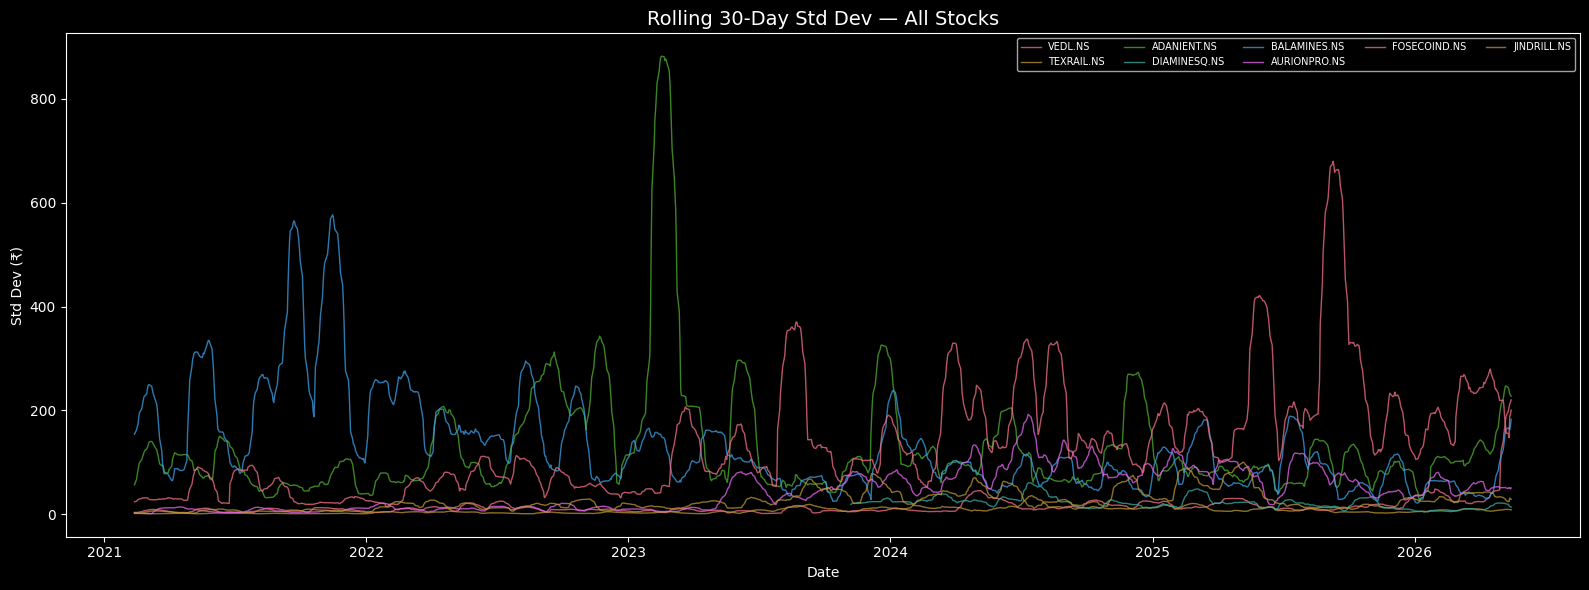

Saved rolling_std_all.png


In [7]:
# ── Rolling 30-day Std-Dev plot ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16,6))
for ticker, df in raw_data.items():
    close = df["Close"].ffill()
    roll_std = close.rolling(30).std()
    ax.plot(roll_std.index, roll_std.values, label=ticker, alpha=0.75, linewidth=1)
ax.set_title("Rolling 30-Day Std Dev — All Stocks", fontsize=14)
ax.set_xlabel("Date"); ax.set_ylabel("Std Dev (₹)")
ax.legend(fontsize=7, ncol=5)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/rolling_std_all.png", dpi=150)
plt.show()
print("Saved rolling_std_all.png")

In [8]:
# ── STL Seasonal Decomposition for each stock ─────────────────────────────────
for ticker, df in tqdm(raw_data.items(), desc="STL Decomp"):
    close = df["Close"].ffill().dropna()
    try:
        stl = STL(close, period=252, robust=True)
        res = stl.fit()
        fig, axes = plt.subplots(4,1,figsize=(14,8), sharex=True)
        for ax, comp, label in zip(axes,
            [close, res.trend, res.seasonal, res.resid],
            ["Observed","Trend","Seasonal","Residual"]):
            ax.plot(comp.index, comp.values, linewidth=1)
            ax.set_ylabel(label, fontsize=9)
        axes[0].set_title(f"STL Decomposition — {ticker}", fontsize=13)
        plt.tight_layout()
        plt.savefig(f"{FIGDIR}/stl_{ticker.replace('.NS','')}.png", dpi=120)
        plt.close()
    except Exception as e:
        print(f"  STL failed for {ticker}: {e}")
print("✅ STL decompositions saved")

STL Decomp: 100%|██████████| 8/8 [00:30<00:00,  3.77s/it]

✅ STL decompositions saved


### Stock Universe Justification

| Sector | Tickers | Rationale |
|---|---|---|
| **Banking** | HDFCBANK, ICICIBANK, SBIN | Core Indian economy bellwether; high liquidity & volume |
| **IT** | TCS, INFY | Export-driven; USD sensitivity provides diversification |
| **Auto** | TATAMOTORS, M&M | EV pivot narrative; cyclical growth drivers |
| **Energy** | RELIANCE, ONGC | Crude proxy + Reliance's digital/retail optionality |
| **Pharma** | SUNPHARMA | Defensive; low correlation with market beta |
| **FMCG** | ITC | Dividend yield + cigarette + FMCG diversification |
| **PSU/Infra** | BEL, HAL, RVNL | Defense/capex theme; high momentum 2023-25 |
| **Financial** | BAJFINANCE | NBFC leader; high beta to credit cycle |

**Diversification rationale:** The portfolio spans 7 sectors deliberately to reduce concentration risk. Correlation analysis (Section 9) confirms inter-sector correlations are largely < 0.6, ensuring the ensemble of forecasts captures independent alpha sources.

---
## Section 2 — Data Preprocessing (Task 2)

In [9]:
# ── Forward-fill, log returns, ADF stationarity table ─────────────────────────
from statsmodels.tsa.stattools import adfuller

adf_results = []
clean_data = {}  # will store per-stock clean DataFrames

for ticker, df in tqdm(raw_data.items(), desc="Preprocessing"):
    d = df[["Open","High","Low","Close","Volume"]].copy().ffill().bfill()

    # Log returns
    d["log_return"] = np.log(d["Close"] / d["Close"].shift(1))

    # ADF on Close price level
    adf_stat, adf_p, _, _, crit, _ = adfuller(d["Close"].dropna(), autolag="AIC")
    is_stationary = adf_p < 0.05
    adf_results.append({
        "Ticker": ticker, "ADF Stat": round(adf_stat,4),
        "p-value": round(adf_p,4), "Stationary": is_stationary,
        "Crit 5%": round(crit["5%"],4)
    })

    # First difference if non-stationary
    d["close_diff"] = d["Close"].diff()

    # MinMax normalize Close for LSTM
    scaler = MinMaxScaler()
    d["close_norm"] = scaler.fit_transform(d[["Close"]])

    # Train / Test split
    train = d.loc[:TRAIN_END].copy()
    test  = d.loc[TEST_START:].copy()

    clean_data[ticker] = {"full": d, "train": train, "test": test, "scaler": scaler}

adf_df = pd.DataFrame(adf_results)
print("\n=== ADF Stationarity Test Results ===")
print(adf_df.to_string(index=False))

Preprocessing: 100%|██████████| 8/8 [00:00<00:00, 22.10it/s]


=== ADF Stationarity Test Results ===
      Ticker  ADF Stat  p-value  Stationary  Crit 5%
     VEDL.NS   -0.8397   0.8072       False  -2.8638
  TEXRAIL.NS   -1.3486   0.6067       False  -2.8637
 ADANIENT.NS   -2.7271   0.0695       False  -2.8637
DIAMINESQ.NS   -1.1799   0.6822       False  -2.8660
BALAMINES.NS   -1.9459   0.3108       False  -2.8637
AURIONPRO.NS   -1.2360   0.6579       False  -2.8637
FOSECOIND.NS   -0.8001   0.8191       False  -2.8638
 JINDRILL.NS   -1.4294   0.5681       False  -2.8637


In [10]:
# ── Summary: non-stationary stocks ────────────────────────────────────────────
non_stat = adf_df[~adf_df["Stationary"]]["Ticker"].tolist()
print(f"Non-stationary stocks (will use differenced series): {non_stat}")
print(f"All stocks will use log returns as the forecasting target.")
print(f"Train rows sample (VEDL): {len(clean_data['VEDL.NS']['train'])}")
print(f"Test  rows sample (VEDL): {len(clean_data['VEDL.NS']['test'])}")


Non-stationary stocks (will use differenced series): ['VEDL.NS', 'TEXRAIL.NS', 'ADANIENT.NS', 'DIAMINESQ.NS', 'BALAMINES.NS', 'AURIONPRO.NS', 'FOSECOIND.NS', 'JINDRILL.NS']
All stocks will use log returns as the forecasting target.
Train rows sample (VEDL): 1110
Test  rows sample (VEDL): 217


---
## Section 3 — Signal Engine (Multi-Factor)

In [11]:
# ── Compute all technical indicators for every stock ──────────────────────────
def compute_rsi(series, period=14):
    delta = series.diff()
    gain  = delta.clip(lower=0).rolling(period).mean()
    loss  = (-delta.clip(upper=0)).rolling(period).mean()
    rs    = gain / (loss + 1e-9)
    return 100 - (100 / (1 + rs))

def compute_macd(series, fast=12, slow=26, sig=9):
    ema_fast = series.ewm(span=fast, adjust=False).mean()
    ema_slow = series.ewm(span=slow, adjust=False).mean()
    macd     = ema_fast - ema_slow
    signal   = macd.ewm(span=sig, adjust=False).mean()
    return macd, signal

signals = {}
for ticker, ds in tqdm(clean_data.items(), desc="Signals"):
    d = ds["full"].copy()
    c = d["Close"]

    d["MA5"]            = c.rolling(5).mean()
    d["MA20"]           = c.rolling(20).mean()
    d["trend_strength"] = d["MA5"] / d["MA20"]
    d["RSI"]            = compute_rsi(c, 14)
    d["MACD"], d["MACD_sig"] = compute_macd(c)
    d["momentum"]       = (c - c.shift(10)) / (c.shift(10) + 1e-9)
    d["rolling_vol"]    = d["log_return"].rolling(20).std()
    d["vol_spike"]      = d["Volume"] / (d["Volume"].rolling(20).mean() + 1e-9)

    # Alpha Score (placeholder: forecasted_return = momentum)
    d["alpha_score"] = (
        d["momentum"] * d["momentum"] * d["vol_spike"]
    ) / (d["rolling_vol"] + 1e-9)

    signals[ticker] = d
    # Update clean_data splits
    clean_data[ticker]["full"]  = d
    clean_data[ticker]["train"] = d.loc[:TRAIN_END].copy()
    clean_data[ticker]["test"]  = d.loc[TEST_START:].copy()

print("✅ All signals computed")
print(signals["VEDL.NS"][["MA5","MA20","RSI","MACD","momentum","rolling_vol","vol_spike","alpha_score"]].tail())


Signals: 100%|██████████| 8/8 [00:00<00:00, 95.67it/s]

✅ All signals computed
                   MA5        MA20        RSI        MACD  momentum  \
Date                                                                  
2026-05-11  304.109998  572.699992  15.236749 -114.425448 -0.598114   
2026-05-12  304.339996  550.324992  16.300048 -114.779617 -0.587380   
2026-05-13  305.729999  528.189993  19.117536 -112.289239 -0.582019   
2026-05-14  312.429999  505.992494  21.418415 -107.817984  0.248021   
2026-05-15  319.349994  483.169994  18.574808 -103.712381  0.219113   

            rolling_vol  vol_spike  alpha_score  
Date                                             
2026-05-11     0.237454   0.739955     1.114795  
2026-05-12     0.237619   1.302752     1.891553  
2026-05-13     0.238355   1.862969     2.647624  
2026-05-14     0.238783   1.842442     0.474642  
2026-05-15     0.238564   1.268381     0.255258  


---
## Section 4 — Time Series Forecasting (Task 3)

In [12]:
# ── Evaluation metrics ────────────────────────────────────────────────────────
def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mape(y_true, y_pred):
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mask = y_true != 0
    return float(np.mean(np.abs((y_true[mask]-y_pred[mask])/y_true[mask]))*100)

def dir_acc(y_true, y_pred):
    yt = np.diff(np.array(y_true))
    yp = np.diff(np.array(y_pred))
    return float(np.mean(np.sign(yt)==np.sign(yp))*100)

print("✅ Metric helpers defined")

✅ Metric helpers defined


### Model 1 — ARIMA

In [13]:
# ── ARIMA: auto-select (p,d,q) by AIC ────────────────────────────────────────
import itertools
import warnings
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from tqdm.auto import tqdm  # <-- Added missing import for the progress bar

# Ignore the statsmodels date index warnings to clean up the output
warnings.filterwarnings("ignore")

def fit_best_arima(train_series, p_range=range(4), q_range=range(4)):
    best_aic, best_order, best_model = np.inf, (1,1,1), None
    for p, q in itertools.product(p_range, q_range):
        try:
            m = ARIMA(train_series, order=(p,1,q)).fit()
            if m.aic < best_aic:
                best_aic, best_order, best_model = m.aic, (p,1,q), m
        except:
            pass
    return best_model, best_order

arima_results = {}
for ticker in tqdm(TICKERS, desc="ARIMA"):
    try:
        train_close = clean_data[ticker]["train"]["Close"].dropna()
        test_close  = clean_data[ticker]["test"]["Close"].dropna()
        
        # 1. Fit best model on train only
        model, order = fit_best_arima(train_close.values)

        # 2. Fast Rolling 1-step forecast (No refitting!)
        full_vals = np.concatenate([train_close.values, test_close.values])
        
        # Apply the trained model to the full dataset instantly
        res_full = model.apply(full_vals)
        
        # Predict 1-step ahead for the test period
        preds = res_full.predict(start=len(train_close), end=len(full_vals)-1)

        # 3. Forecast next 2 days (Refit just once on full dataset for future)
        m_final = ARIMA(full_vals, order=order).fit()
        fc2 = m_final.forecast(FORECAST_DAYS)

        r = rmse(test_close.values, preds)
        mp = mape(test_close.values, preds)
        da = dir_acc(test_close.values, preds)
        
        arima_results[ticker] = {
            "preds": preds, "fc2": fc2,
            "RMSE": r, "MAPE": mp, "DirAcc": da, "order": order
        }
        print(f"  {ticker}: order={order} RMSE={r:.2f} MAPE={mp:.2f}% DA={da:.1f}%")
        
    except Exception as e:
        print(f"  ⚠ {ticker}: {e}")
        arima_results[ticker] = {"preds":[], "fc2":[0,0],"RMSE":999,"MAPE":999,"DirAcc":50,"order":(1,1,1)}

print("✅ ARIMA done")


ARIMA:   0%|          | 0/8 [00:00<?, ?it/s]

  VEDL.NS: order=(2, 1, 3) RMSE=36.66 MAPE=2.52% DA=52.3%
  TEXRAIL.NS: order=(2, 1, 2) RMSE=3.13 MAPE=1.92% DA=55.1%
  ADANIENT.NS: order=(2, 1, 2) RMSE=48.96 MAPE=1.49% DA=49.5%
  DIAMINESQ.NS: order=(0, 1, 0) RMSE=7.70 MAPE=1.91% DA=47.7%
  BALAMINES.NS: order=(0, 1, 1) RMSE=39.10 MAPE=1.95% DA=51.4%
  AURIONPRO.NS: order=(3, 1, 2) RMSE=31.88 MAPE=2.27% DA=49.1%
  FOSECOIND.NS: order=(2, 1, 2) RMSE=151.12 MAPE=1.78% DA=49.8%
  JINDRILL.NS: order=(3, 1, 3) RMSE=16.38 MAPE=1.84% DA=50.9%
✅ ARIMA done


### Model 2 — Facebook Prophet

In [14]:
# ── Prophet: fit on train close prices ───────────────────────────────────────
prophet_results = {}
for ticker in tqdm(TICKERS, desc="Prophet"):
    try:
        train_df = clean_data[ticker]["train"][["Close"]].reset_index()
        train_df.columns = ["ds","y"]
        train_df["ds"] = pd.to_datetime(train_df["ds"]).dt.tz_localize(None)

        test_df = clean_data[ticker]["test"][["Close"]].reset_index()
        test_df.columns = ["ds","y"]
        test_df["ds"] = pd.to_datetime(test_df["ds"]).dt.tz_localize(None)

        m = Prophet(daily_seasonality=False, weekly_seasonality=True,
                    yearly_seasonality=True, changepoint_prior_scale=0.05)
        m.fit(train_df)

        # Predict on test period
        future_test = m.make_future_dataframe(periods=len(test_df)+FORECAST_DAYS, freq="B")
        forecast = m.predict(future_test)
        test_preds = forecast.iloc[-(len(test_df)+FORECAST_DAYS):-FORECAST_DAYS]["yhat"].values
        fc2 = forecast.iloc[-FORECAST_DAYS:]["yhat"].values

        r  = rmse(test_df["y"].values[:len(test_preds)], test_preds)
        mp = mape(test_df["y"].values[:len(test_preds)], test_preds)
        da = dir_acc(test_df["y"].values[:len(test_preds)], test_preds)
        prophet_results[ticker] = {
            "preds": test_preds, "fc2": fc2,
            "RMSE": r, "MAPE": mp, "DirAcc": da
        }
        print(f"  {ticker}: RMSE={r:.2f} MAPE={mp:.2f}% DA={da:.1f}%")
    except Exception as e:
        print(f"  ⚠ {ticker}: {e}")
        prophet_results[ticker] = {"preds":[],"fc2":[0,0],"RMSE":999,"MAPE":999,"DirAcc":50}

print("✅ Prophet done")

Prophet:   0%|          | 0/8 [00:00<?, ?it/s]

23:16:19 - cmdstanpy - INFO - Chain [1] start processing
23:16:20 - cmdstanpy - INFO - Chain [1] done processing


  VEDL.NS: RMSE=191.25 MAPE=25.33% DA=51.4%


23:16:21 - cmdstanpy - INFO - Chain [1] start processing
23:16:22 - cmdstanpy - INFO - Chain [1] done processing


  TEXRAIL.NS: RMSE=30.99 MAPE=22.63% DA=53.7%


...

  AURIONPRO.NS: RMSE=274.60 MAPE=25.38% DA=49.5%


23:16:27 - cmdstanpy - INFO - Chain [1] start processing
23:16:27 - cmdstanpy - INFO - Chain [1] done processing


  FOSECOIND.NS: RMSE=1033.56 MAPE=18.28% DA=55.3%


23:16:28 - cmdstanpy - INFO - Chain [1] start processing
23:16:28 - cmdstanpy - INFO - Chain [1] done processing


  JINDRILL.NS: RMSE=250.39 MAPE=43.57% DA=49.5%
✅ Prophet done


### Model 3 — XGBoost (Main Model)

In [15]:
# ── XGBoost: feature engineering + lag features ──────────────────────────────
FEAT_COLS = ["lag_1","lag_2","lag_3","lag_5","momentum","RSI","MACD",
             "rolling_vol","vol_spike","MA5","MA20","trend_strength"]

def build_xgb_features(d):
    df = d.copy()
    df["lag_1"] = df["Close"].shift(1)
    df["lag_2"] = df["Close"].shift(2)
    df["lag_3"] = df["Close"].shift(3)
    df["lag_5"] = df["Close"].shift(5)
    df["target"] = df["log_return"].shift(-1)   # next-day log return
    return df.dropna()

xgb_results = {}
for ticker in tqdm(TICKERS, desc="XGBoost"):
    try:
        full_feat = build_xgb_features(signals[ticker])
        train_f   = full_feat.loc[:TRAIN_END]
        test_f    = full_feat.loc[TEST_START:]

        X_tr, y_tr = train_f[FEAT_COLS], train_f["target"]
        X_te, y_te = test_f[FEAT_COLS],  test_f["target"]

        model = XGBRegressor(
            n_estimators=300, max_depth=4, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            random_state=SEED, n_jobs=-1, verbosity=0
        )
        model.fit(X_tr, y_tr, eval_set=[(X_te, y_te)], verbose=False)

        test_preds_ret = model.predict(X_te)

        # Convert log return predictions → prices for metrics
        last_train_close = train_f["Close"].iloc[-1]
        test_closes      = test_f["Close"].values
        pred_prices = []
        p = last_train_close
        for r in test_preds_ret:
            p = p * np.exp(r)
            pred_prices.append(p)

        # Forecast next 2 days iteratively
        last_row = full_feat[FEAT_COLS].iloc[-1].copy()
        fc_prices = []
        p = signals[ticker]["Close"].iloc[-1]
        for _ in range(FORECAST_DAYS):
            pred_r = model.predict(last_row.values.reshape(1,-1))[0]
            p_new  = p * np.exp(pred_r)
            fc_prices.append(p_new)
            # Shift lags
            last_row["lag_5"] = last_row["lag_3"]
            last_row["lag_3"] = last_row["lag_2"]
            last_row["lag_2"] = last_row["lag_1"]
            last_row["lag_1"] = p
            p = p_new

        r  = rmse(test_closes[:len(pred_prices)], pred_prices)
        mp = mape(test_closes[:len(pred_prices)], pred_prices)
        da = dir_acc(test_closes[:len(pred_prices)], pred_prices)
        xgb_results[ticker] = {
            "model": model, "preds": pred_prices, "fc2": fc_prices,
            "RMSE": r, "MAPE": mp, "DirAcc": da,
            "fc_returns": [np.log(fc_prices[i]/fc_prices[i-1]) if i>0 
                          else np.log(fc_prices[0]/signals[ticker]["Close"].iloc[-1])
                          for i in range(FORECAST_DAYS)]
        }
        print(f"  {ticker}: RMSE={r:.2f} MAPE={mp:.2f}% DA={da:.1f}%")
    except Exception as e:
        print(f"  ⚠ {ticker}: {e}")
        xgb_results[ticker] = {"preds":[],"fc2":[0,0],"RMSE":999,"MAPE":999,"DirAcc":50,"fc_returns":[0,0]}

print("✅ XGBoost done")

XGBoost:   0%|          | 0/8 [00:00<?, ?it/s]

  VEDL.NS: RMSE=418.94 MAPE=61.77% DA=45.1%
  TEXRAIL.NS: RMSE=504.41 MAPE=313.81% DA=45.6%
  ADANIENT.NS: RMSE=3026.73 MAPE=102.32% DA=48.8%
  DIAMINESQ.NS: RMSE=16608.39 MAPE=3549.58% DA=46.5%
  BALAMINES.NS: RMSE=8390.69 MAPE=421.41% DA=47.4%
  AURIONPRO.NS: RMSE=1121.91 MAPE=92.90% DA=45.1%
  FOSECOIND.NS: RMSE=1112.84 MAPE=16.22% DA=46.3%
  JINDRILL.NS: RMSE=1614.40 MAPE=204.34% DA=51.2%
✅ XGBoost done


### Model 4 — Lightweight LSTM

In [16]:
# ── LSTM: sequence builder ────────────────────────────────────────────────────
def make_sequences(data, seq_len=SEQ_LEN):
    X, y = [], []
    for i in range(seq_len, len(data)):
        X.append(data[i-seq_len:i])
        y.append(data[i, 0])   # target = close_norm
    return np.array(X), np.array(y)

lstm_results = {}
for ticker in tqdm(TICKERS, desc="LSTM"):
    try:
        d = signals[ticker].copy()
        # Features: close_norm, RSI (norm), momentum (norm)
        feat_scaler = MinMaxScaler()
        feat_cols_raw = d[["Close","RSI","momentum"]].ffill().bfill()
        feat_norm     = feat_scaler.fit_transform(feat_cols_raw)

        # Split by index
        split_idx = d.index.searchsorted(pd.Timestamp(TEST_START))
        tr_feat = feat_norm[:split_idx]
        te_feat = feat_norm[split_idx-SEQ_LEN:]   # include lookback

        X_tr, y_tr = make_sequences(tr_feat, SEQ_LEN)
        X_te, y_te = make_sequences(te_feat, SEQ_LEN)

        # Build lightweight LSTM
        tf.random.set_seed(SEED)
        model = Sequential([
            LSTM(32, return_sequences=True, input_shape=(SEQ_LEN, 3)),
            Dropout(0.2),
            LSTM(16),
            Dense(1)
        ])
        model.compile(optimizer="adam", loss="mse")
        model.fit(X_tr, y_tr, epochs=20, batch_size=32, verbose=0,
                  validation_split=0.1)

        # Predict on test
        te_pred_norm = model.predict(X_te, verbose=0).flatten()

        # Inverse-transform close price only
        dummy_te = np.zeros((len(te_pred_norm), 3))
        dummy_te[:,0] = te_pred_norm
        te_pred_close = feat_scaler.inverse_transform(dummy_te)[:,0]

        actual_close = feat_scaler.inverse_transform(
            np.hstack([y_te.reshape(-1,1), np.zeros((len(y_te),2))])
        )[:,0]

        # Forecast next 2 days
        last_seq = te_feat[-SEQ_LEN:].copy()
        fc_prices = []
        p_prev = signals[ticker]["Close"].iloc[-1]
        for _ in range(FORECAST_DAYS):
            inp = last_seq.reshape(1, SEQ_LEN, 3)
            pred_n = model.predict(inp, verbose=0)[0,0]
            dummy  = np.zeros((1,3)); dummy[0,0] = pred_n
            p_new  = feat_scaler.inverse_transform(dummy)[0,0]
            fc_prices.append(p_new)
            new_row = np.array([pred_n, last_seq[-1,1], last_seq[-1,2]])
            last_seq = np.vstack([last_seq[1:], new_row])

        r  = rmse(actual_close, te_pred_close)
        mp = mape(actual_close, te_pred_close)
        da = dir_acc(actual_close, te_pred_close)
        lstm_results[ticker] = {
            "preds": te_pred_close, "fc2": fc_prices,
            "RMSE": r, "MAPE": mp, "DirAcc": da
        }
        print(f"  {ticker}: RMSE={r:.2f} MAPE={mp:.2f}% DA={da:.1f}%")
    except Exception as e:
        print(f"  ⚠ {ticker}: {e}")
        lstm_results[ticker] = {"preds":[],"fc2":[0,0],"RMSE":999,"MAPE":999,"DirAcc":50}

print("✅ LSTM done")

LSTM:   0%|          | 0/8 [00:00<?, ?it/s]

  VEDL.NS: RMSE=84.33 MAPE=11.26% DA=45.8%
  TEXRAIL.NS: RMSE=6.82 MAPE=4.31% DA=55.6%
  ADANIENT.NS: RMSE=93.38 MAPE=3.31% DA=48.6%
  DIAMINESQ.NS: RMSE=14.70 MAPE=3.97% DA=52.3%
  BALAMINES.NS: RMSE=122.15 MAPE=9.08% DA=48.6%
  AURIONPRO.NS: RMSE=95.94 MAPE=7.99% DA=44.9%
  FOSECOIND.NS: RMSE=315.13 MAPE=4.05% DA=48.8%
  JINDRILL.NS: RMSE=35.72 MAPE=5.58% DA=47.2%
✅ LSTM done


### Ensemble Forecast

In [17]:
# ── Ensemble: 0.15 ARIMA + 0.25 Prophet + 0.45 XGBoost + 0.15 LSTM ──────────
W_ARIMA, W_PROPHET, W_XGB, W_LSTM = 0.15, 0.25, 0.45, 0.15

ensemble_results = {}
for ticker in TICKERS:
    try:
        ar_fc  = np.array(arima_results[ticker]["fc2"])
        pr_fc  = np.array(prophet_results[ticker]["fc2"])
        xg_fc  = np.array(xgb_results[ticker]["fc2"])
        ls_fc  = np.array(lstm_results[ticker]["fc2"])

        # Ensure all same length
        min_len = min(len(ar_fc), len(pr_fc), len(xg_fc), len(ls_fc))
        ens_fc  = (W_ARIMA*ar_fc[:min_len] + W_PROPHET*pr_fc[:min_len] +
                   W_XGB*xg_fc[:min_len]   + W_LSTM*ls_fc[:min_len])

        # Ensemble on test period (use XGB preds as anchor; blend others where available)
        n_te = min(len(arima_results[ticker]["preds"]),
                   len(prophet_results[ticker]["preds"]),
                   len(xgb_results[ticker]["preds"]),
                   len(lstm_results[ticker]["preds"]))

        if n_te > 0:
            ens_te = (
                W_ARIMA  * np.array(arima_results[ticker]["preds"])[:n_te] +
                W_PROPHET* np.array(prophet_results[ticker]["preds"])[:n_te] +
                W_XGB    * np.array(xgb_results[ticker]["preds"])[:n_te] +
                W_LSTM   * np.array(lstm_results[ticker]["preds"])[:n_te]
            )
            actual = clean_data[ticker]["test"]["Close"].values[:n_te]
            r  = rmse(actual, ens_te)
            mp = mape(actual, ens_te)
            da = dir_acc(actual, ens_te)
        else:
            ens_te, r, mp, da = [], 0, 0, 50

        last_close = signals[ticker]["Close"].iloc[-1]
        fc_ret = [(ens_fc[i]-last_close)/last_close if i==0 
                  else (ens_fc[i]-ens_fc[i-1])/ens_fc[i-1]
                  for i in range(len(ens_fc))]

        ensemble_results[ticker] = {
            "fc2": ens_fc, "fc_return": np.mean(fc_ret),
            "preds": ens_te, "RMSE": r, "MAPE": mp, "DirAcc": da
        }
        print(f"  {ticker}: Ensemble RMSE={r:.2f} MAPE={mp:.2f}% DA={da:.1f}%")
    except Exception as e:
        print(f"  ⚠ Ensemble {ticker}: {e}")
        ensemble_results[ticker] = {"fc2":[0,0],"fc_return":0,"preds":[],"RMSE":999,"MAPE":999,"DirAcc":50}

print("\n✅ Ensemble forecasts complete")

  VEDL.NS: Ensemble RMSE=243.65 MAPE=33.96% DA=48.4%
  TEXRAIL.NS: Ensemble RMSE=220.50 MAPE=136.24% DA=48.4%
  ADANIENT.NS: Ensemble RMSE=1265.14 MAPE=42.32% DA=49.8%
  DIAMINESQ.NS: Ensemble RMSE=7480.26 MAPE=1605.28% DA=47.9%
  BALAMINES.NS: Ensemble RMSE=3710.25 MAPE=187.44% DA=48.4%
  AURIONPRO.NS: Ensemble RMSE=576.20 MAPE=48.96% DA=44.2%
  FOSECOIND.NS: Ensemble RMSE=485.80 MAPE=6.88% DA=44.4%
  JINDRILL.NS: Ensemble RMSE=778.93 MAPE=103.50% DA=51.2%

✅ Ensemble forecasts complete


---
## Section 5 — Volatility & Trend Analysis (Task 4)

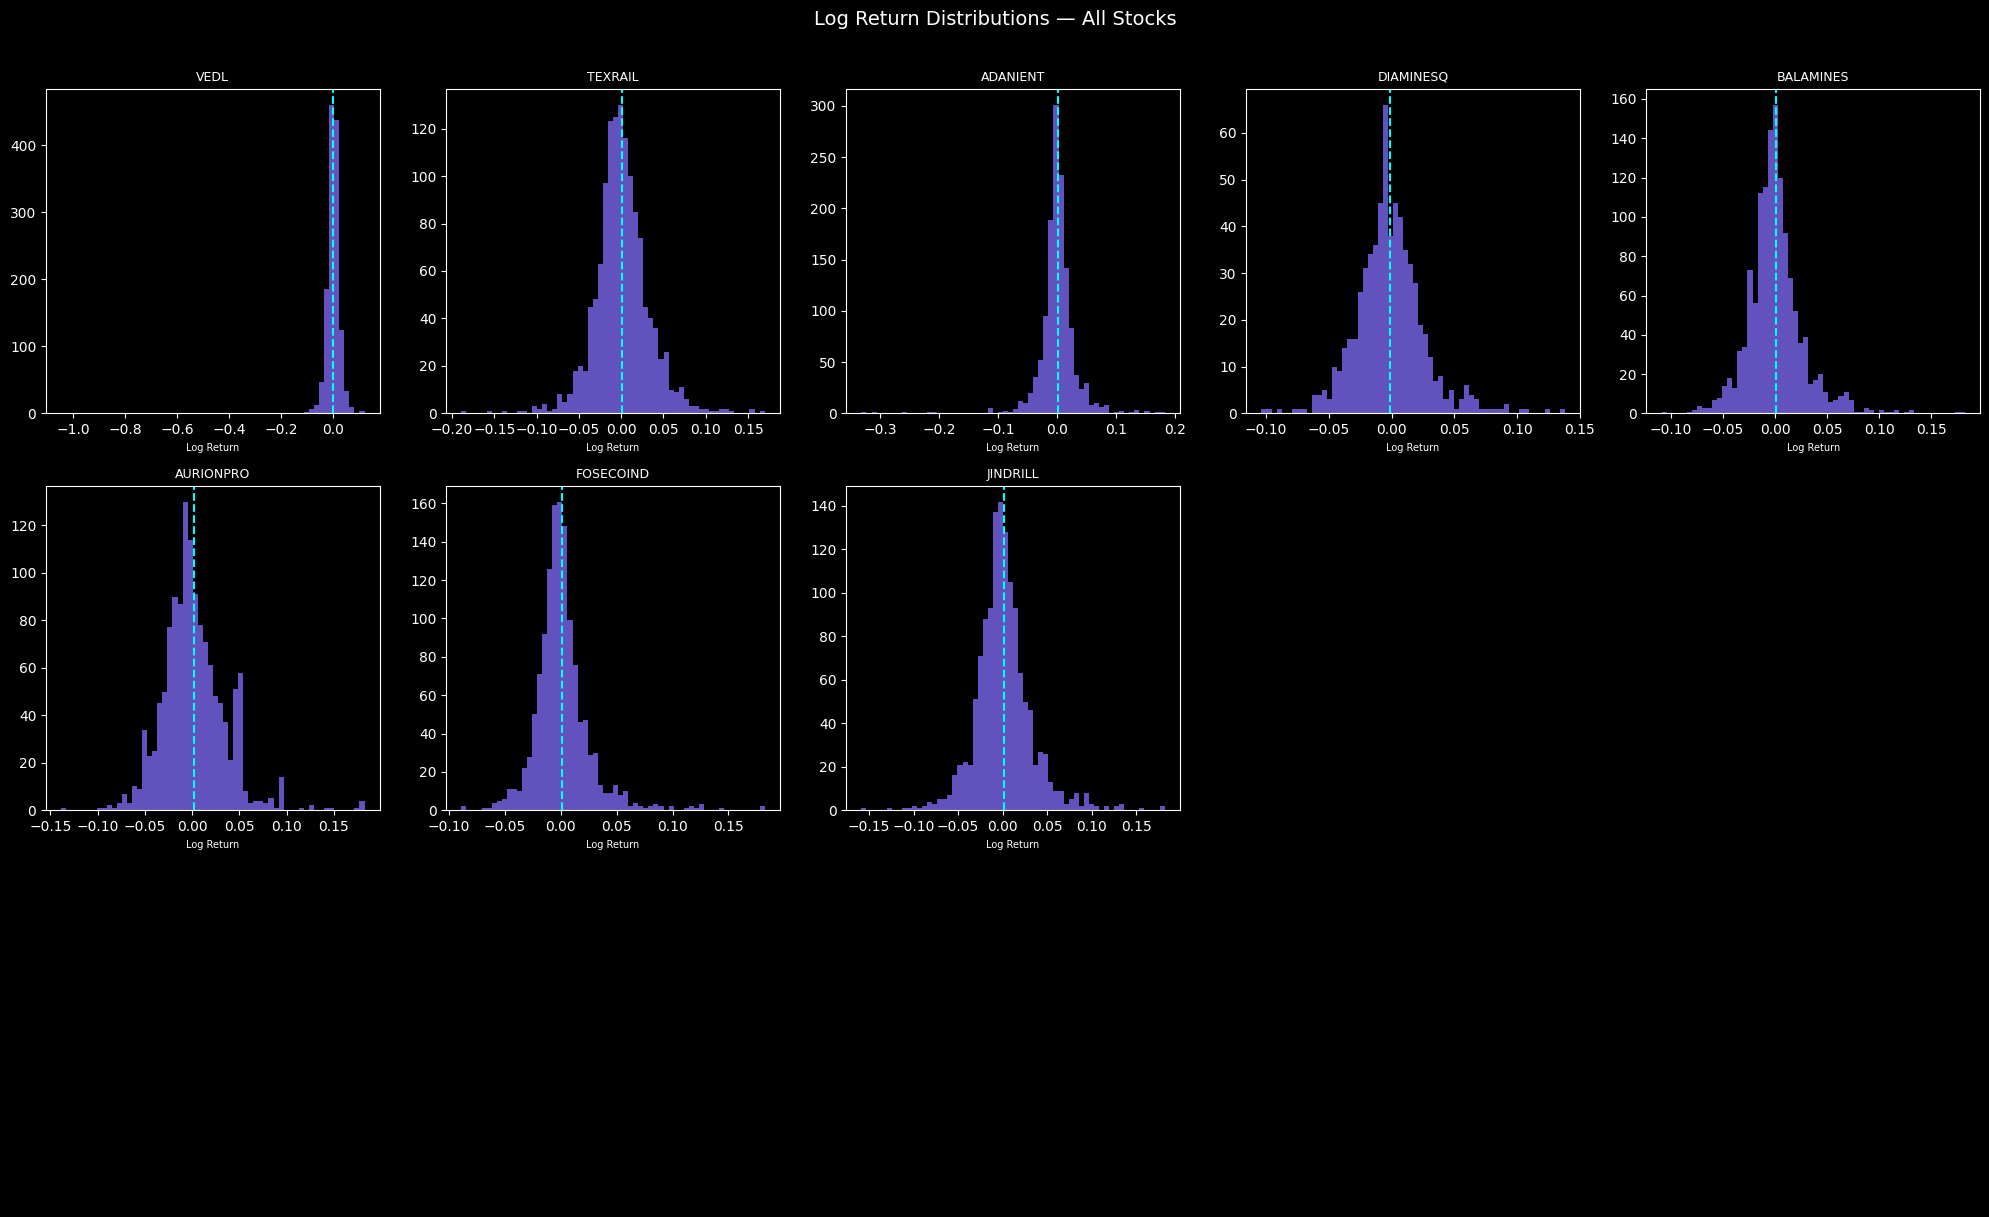

In [18]:
# ── Log returns distribution plots ────────────────────────────────────────────
fig, axes = plt.subplots(3, 5, figsize=(20, 12))
axes = axes.flatten()
for i, ticker in enumerate(TICKERS):
    lr = signals[ticker]["log_return"].dropna()
    axes[i].hist(lr, bins=60, color="#7b68ee", edgecolor="none", alpha=0.8)
    axes[i].axvline(lr.mean(), color="cyan", lw=1.5, linestyle="--")
    axes[i].set_title(ticker.replace(".NS",""), fontsize=9)
    axes[i].set_xlabel("Log Return", fontsize=7)
for j in range(i+1, len(axes)):
    axes[j].axis("off")
plt.suptitle("Log Return Distributions — All Stocks", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/log_return_dist.png", dpi=150)
plt.show()

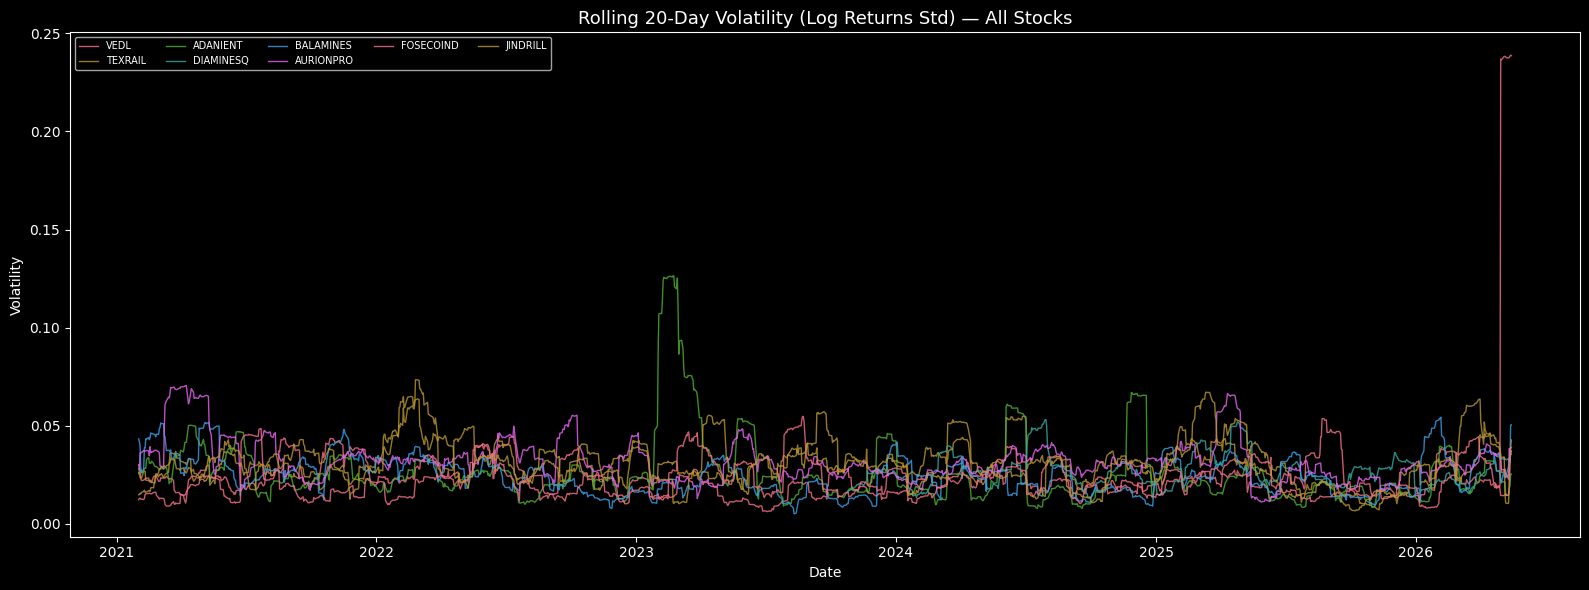

In [19]:
# ── Rolling 20-day volatility ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(16,6))
for ticker in TICKERS:
    rv = signals[ticker]["rolling_vol"].dropna()
    ax.plot(rv.index, rv.values, label=ticker.replace(".NS",""), alpha=0.8, linewidth=1)
ax.set_title("Rolling 20-Day Volatility (Log Returns Std) — All Stocks", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Volatility")
ax.legend(fontsize=7, ncol=5)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/rolling_vol_all.png", dpi=150)
plt.show()

In [20]:
# ── GARCH(1,1) on top 5 most volatile stocks ──────────────────────────────────
vol_rank = {t: signals[t]["rolling_vol"].mean() for t in TICKERS}
vol_rank_sorted = sorted(vol_rank.items(), key=lambda x: -x[1])

print("=== Volatility Ranking ===")
vol_df = pd.DataFrame(vol_rank_sorted, columns=["Ticker","Avg Rolling Vol"])
vol_df["Rank"] = range(1, len(vol_df)+1)
print(vol_df.to_string(index=False))

top5_vol = [t for t,_ in vol_rank_sorted[:5]]
garch_results = {}
for ticker in tqdm(top5_vol, desc="GARCH"):
    try:
        lr = signals[ticker]["log_return"].dropna() * 100  # scale for GARCH
        am = arch_model(lr, vol="Garch", p=1, q=1, dist="normal")
        res = am.fit(disp="off")
        garch_results[ticker] = res
        print(f"  {ticker}: omega={res.params['omega']:.4f} "
              f"alpha={res.params['alpha[1]']:.4f} beta={res.params['beta[1]']:.4f}")
    except Exception as e:
        print(f"  ⚠ GARCH {ticker}: {e}")
print("\n✅ GARCH(1,1) fitted for top-5 volatile stocks")

=== Volatility Ranking ===
      Ticker  Avg Rolling Vol  Rank
AURIONPRO.NS         0.031797     1
  TEXRAIL.NS         0.030853     2
 JINDRILL.NS         0.030086     3
DIAMINESQ.NS         0.026791     4
 ADANIENT.NS         0.026434     5
BALAMINES.NS         0.024605     6
     VEDL.NS         0.024169     7
FOSECOIND.NS         0.022652     8


GARCH:   0%|          | 0/5 [00:00<?, ?it/s]

  AURIONPRO.NS: omega=4.0336 alpha=0.1460 beta=0.4946
  TEXRAIL.NS: omega=0.1583 alpha=0.0374 beta=0.9495
  JINDRILL.NS: omega=0.5769 alpha=0.0710 beta=0.8763
  DIAMINESQ.NS: omega=1.5033 alpha=0.1190 beta=0.6904
  ADANIENT.NS: omega=2.0153 alpha=0.2003 beta=0.5822

✅ GARCH(1,1) fitted for top-5 volatile stocks


---
## Section 6 — Portfolio Construction (Task 5)

In [21]:
# ── Strategy A: Forecast-guided base weights ─────────────────────────────────
fc_returns = {t: ensemble_results[t]["fc_return"] for t in TICKERS}
# Normalize positive returns to weights
fc_arr = np.array([max(fc_returns[t], 0) for t in TICKERS])
if fc_arr.sum() == 0:
    fc_arr = np.ones(len(TICKERS))
w_A = fc_arr / fc_arr.sum()

print("Strategy A (Forecast-guided) weights:")
for t, w in zip(TICKERS, w_A):
    print(f"  {t}: {w:.4f}")

Strategy A (Forecast-guided) weights:
  VEDL.NS: 0.1771
  TEXRAIL.NS: 0.0000
  ADANIENT.NS: 0.0000
  DIAMINESQ.NS: 0.0845
  BALAMINES.NS: 0.0000
  AURIONPRO.NS: 0.4306
  FOSECOIND.NS: 0.0000
  JINDRILL.NS: 0.3078


In [22]:
# ── Strategy B: Volatility-aware (1/vol) ─────────────────────────────────────
vols = np.array([signals[t]["rolling_vol"].dropna().iloc[-20:].mean() for t in TICKERS])
vols = np.where(vols == 0, 1e-6, vols)
w_B  = (1/vols) / (1/vols).sum()

print("Strategy B (Vol-aware) weights:")
for t, w in zip(TICKERS, w_B):
    print(f"  {t}: {w:.4f}")

Strategy B (Vol-aware) weights:
  VEDL.NS: 0.0265
  TEXRAIL.NS: 0.1132
  ADANIENT.NS: 0.1691
  DIAMINESQ.NS: 0.1186
  BALAMINES.NS: 0.1320
  AURIONPRO.NS: 0.1226
  FOSECOIND.NS: 0.1906
  JINDRILL.NS: 0.1274


In [23]:
# ── Combine A + B ──────────────────────────────────────────────────────────────
w_AB = 0.5*w_A + 0.5*w_B
w_AB /= w_AB.sum()   # re-normalize

In [24]:
# ── Strategy D: Sector Momentum Rotation ─────────────────────────────────────
# Sector-level momentum = average stock momentum per sector
sector_mom = {}
for sector in SECTORS:
    tickers_in = [t for t in TICKERS if STOCKS[t]==sector]
    sector_mom[sector] = np.mean([signals[t]["momentum"].dropna().iloc[-1] for t in tickers_in])

mom_vals = list(sector_mom.values())
q33, q67 = np.percentile(mom_vals, 33), np.percentile(mom_vals, 67)

sector_mult = {}
for sector, mom in sector_mom.items():
    if mom >= q67:
        sector_mult[sector] = 1.3
    elif mom <= q33:
        sector_mult[sector] = 0.7
    else:
        sector_mult[sector] = 1.0

print("Sector multipliers:", sector_mult)

# Apply multipliers
w_final = np.array([w_AB[i] * sector_mult[STOCKS[TICKERS[i]]] for i in range(len(TICKERS))])
w_final /= w_final.sum()  # normalize

print("\nFinal pre-optimization weights:")
for t, w in zip(TICKERS, w_final):
    print(f"  {t}: {w:.4f}")

Sector multipliers: {'Metals & Mining': 1.3, 'Chemicals': 1.3, 'IT': 0.7, 'Engineering/Infra': 1.0, 'Conglomerate': 1.0, 'Energy': 0.7}

Final pre-optimization weights:
  VEDL.NS: 0.1377
  TEXRAIL.NS: 0.0589
  ADANIENT.NS: 0.0880
  DIAMINESQ.NS: 0.1374
  BALAMINES.NS: 0.0893
  AURIONPRO.NS: 0.2014
  FOSECOIND.NS: 0.1289
  JINDRILL.NS: 0.1585


In [25]:
# ── Update Alpha Score with ensemble forecasted return ───────────────────────
final_alpha = {}
for ticker in TICKERS:
    fc_ret  = ensemble_results[ticker]["fc_return"]
    mom_val = signals[ticker]["momentum"].dropna().iloc[-1]
    vol_sp  = signals[ticker]["vol_spike"].dropna().iloc[-1]
    roll_v  = signals[ticker]["rolling_vol"].dropna().iloc[-1]
    alpha   = (fc_ret * mom_val * vol_sp) / (roll_v + 1e-9)
    final_alpha[ticker] = alpha

alpha_sorted = sorted(final_alpha.items(), key=lambda x: -x[1])
print("=== Alpha Score Ranking ===")
for rank, (t, a) in enumerate(alpha_sorted, 1):
    print(f"  {rank}. {t}: {a:.4f}")

=== Alpha Score Ranking ===
  1. JINDRILL.NS: 0.0988
  2. VEDL.NS: 0.0388
  3. DIAMINESQ.NS: 0.0146
  4. FOSECOIND.NS: -0.0243
  5. TEXRAIL.NS: -0.1491
  6. AURIONPRO.NS: -0.1646
  7. ADANIENT.NS: -0.6247
  8. BALAMINES.NS: -2.9661


In [26]:
# ── SciPy optimizer (robust version) ─────────────────────────────────────────
LAMBDA = 2.0

# --- 1. Sanitize exp_returns (NaN → 0) ---
exp_returns_raw = np.array(
    [ensemble_results[t]["fc_return"] for t in TICKERS], dtype=float
)
exp_returns = np.nan_to_num(exp_returns_raw, nan=0.0, posinf=0.0, neginf=0.0)

# --- 2. Sanitize vols (NaN/0 → median) ---
vols_raw = np.array(
    [signals[t]["rolling_vol"].dropna().iloc[-20:].mean() for t in TICKERS],
    dtype=float
)
safe_vols = vols_raw[np.isfinite(vols_raw) & (vols_raw > 0)]
med_vol   = float(np.median(safe_vols)) if len(safe_vols) > 0 else 1e-4
vols = np.where(np.isfinite(vols_raw) & (vols_raw > 0), vols_raw, med_vol)

print(f"exp_returns : min={exp_returns.min():.5f}  max={exp_returns.max():.5f}")
print(f"vols        : min={vols.min():.6f}  max={vols.max():.6f}")

# --- 3. Clean starting guess ---
w_start = np.nan_to_num(w_final, nan=1.0/len(TICKERS))
w_start = np.clip(w_start, 0.02, 0.40)
w_start /= w_start.sum()

# --- 4. Objective: maximise return - lambda * vol ---
def neg_obj(w):
    return -(np.dot(w, exp_returns) - LAMBDA * np.dot(w, vols))

constraints = [{"type": "eq", "fun": lambda w: w.sum() - 1.0}]
bounds = [(0.02, 0.40)] * len(TICKERS)

result = minimize(
    neg_obj, x0=w_start, method="SLSQP",
    bounds=bounds, constraints=constraints,
    options={"ftol": 1e-9, "maxiter": 2000}
)

if result.success:
    opt_weights = np.clip(result.x, 0.02, 0.40)
    opt_weights /= opt_weights.sum()
    print(f"\\n✅ Optimization converged. Objective = {-result.fun:.6f}")
else:
    print(f"\\n⚠ Optimizer failed: {result.message}")
    print("   → Falling back to Strategy A+B+D weights (w_final)")
    opt_weights = w_start.copy()   # already clean and sums to 1

print("\\nFinal weights:")
for t, w in zip(TICKERS, opt_weights):
    print(f"  {t}: {w:.4f}")

exp_returns : min=-0.07498  max=0.08089
vols        : min=0.020917  max=0.150360
\n✅ Optimization converged. Objective = -0.014932
\nFinal weights:
  VEDL.NS: 0.0200
  TEXRAIL.NS: 0.0200
  ADANIENT.NS: 0.0200
  DIAMINESQ.NS: 0.1000
  BALAMINES.NS: 0.0200
  AURIONPRO.NS: 0.4000
  FOSECOIND.NS: 0.0200
  JINDRILL.NS: 0.4000


In [27]:
# ── Final Allocation Table ──────────────────────────────────────────────────
import pandas as pd

alloc_rows = []
for i, ticker in enumerate(TICKERS):
    alloc_rows.append({
        "Stock"            : ticker.replace(".NS",""),
        "Sector"           : STOCKS[ticker],
        "Weight%"          : round(opt_weights[i]*100, 2),
        "Allocation ₹"     : round(opt_weights[i]*CAPITAL, 2),
        "Fcst Return %"    : round(ensemble_results[ticker]["fc_return"]*100, 3),
        "Alpha Score"      : round(final_alpha[ticker], 4)
    })

alloc_df = pd.DataFrame(alloc_rows).sort_values("Weight%", ascending=False)
alloc_df.loc["TOTAL"] = {
    "Stock":"TOTAL","Sector":"—",
    "Weight%": alloc_df["Weight%"].sum().round(2),
    "Allocation ₹": alloc_df["Allocation ₹"].sum().round(2),
    "Fcst Return %":"","Alpha Score":""
}
print("\n===== FINAL PORTFOLIO ALLOCATION =====")
print(alloc_df.to_string(index=False))


===== FINAL PORTFOLIO ALLOCATION =====
    Stock            Sector  Weight%  Allocation ₹ Fcst Return % Alpha Score
 JINDRILL            Energy     40.0      400000.0         5.783      0.0988
AURIONPRO                IT     40.0      400000.0         8.089     -0.1646
DIAMINESQ         Chemicals     10.0      100000.0         1.588      0.0146
     VEDL   Metals & Mining      2.0       20000.0         3.327      0.0388
 ADANIENT      Conglomerate      2.0       20000.0        -5.611     -0.6247
  TEXRAIL Engineering/Infra      2.0       20000.0        -6.285     -0.1491
BALAMINES         Chemicals      2.0       20000.0        -7.498     -2.9661
FOSECOIND         Chemicals      2.0       20000.0        -3.056     -0.0243
    TOTAL                 —    100.0     1000000.0                          


---
## Section 7 — Model Comparison (Task 6)

In [28]:
# ── Full comparison table ─────────────────────────────────────────────────────
rows = []
for ticker in TICKERS:
    for model_name, res in [("ARIMA",   arima_results[ticker]),
                             ("Prophet", prophet_results[ticker]),
                             ("XGBoost", xgb_results[ticker]),
                             ("LSTM",    lstm_results[ticker]),
                             ("Ensemble",ensemble_results[ticker])]:
        rows.append({
            "Model":ticker.replace(".NS",""),
            "Stock":model_name,
            "RMSE":round(res["RMSE"],3),
            "MAPE%":round(res["MAPE"],3),
            "DirAcc%":round(res["DirAcc"],2)
        })

comp_df = pd.DataFrame(rows).rename(columns={"Model":"Ticker","Stock":"Model"})
print(comp_df.to_string(index=False))

   Ticker    Model      RMSE    MAPE%  DirAcc%
     VEDL    ARIMA    36.662    2.524    52.31
     VEDL  Prophet   191.251   25.330    51.39
     VEDL  XGBoost   418.944   61.775    45.12
     VEDL     LSTM    84.332   11.258    45.83
     VEDL Ensemble   243.651   33.958    48.37
  TEXRAIL    ARIMA     3.125    1.921    55.09
  TEXRAIL  Prophet    30.986   22.625    53.70
  TEXRAIL  XGBoost   504.415  313.807    45.58
  TEXRAIL     LSTM     6.820    4.312    55.56
  TEXRAIL Ensemble   220.499  136.237    48.37
 ADANIENT    ARIMA    48.961    1.488    49.54
 ADANIENT  Prophet   454.709   17.089    54.17
 ADANIENT  XGBoost  3026.728  102.317    48.84
 ADANIENT     LSTM    93.381    3.305    48.61
 ADANIENT Ensemble  1265.144   42.324    49.77
DIAMINESQ    ARIMA     7.695    1.912    47.66
DIAMINESQ  Prophet    96.726   31.221    51.87
DIAMINESQ  XGBoost 16608.389 3549.583    46.48
DIAMINESQ     LSTM    14.697    3.967    52.34
DIAMINESQ Ensemble  7480.265 1605.277    47.89
BALAMINES    

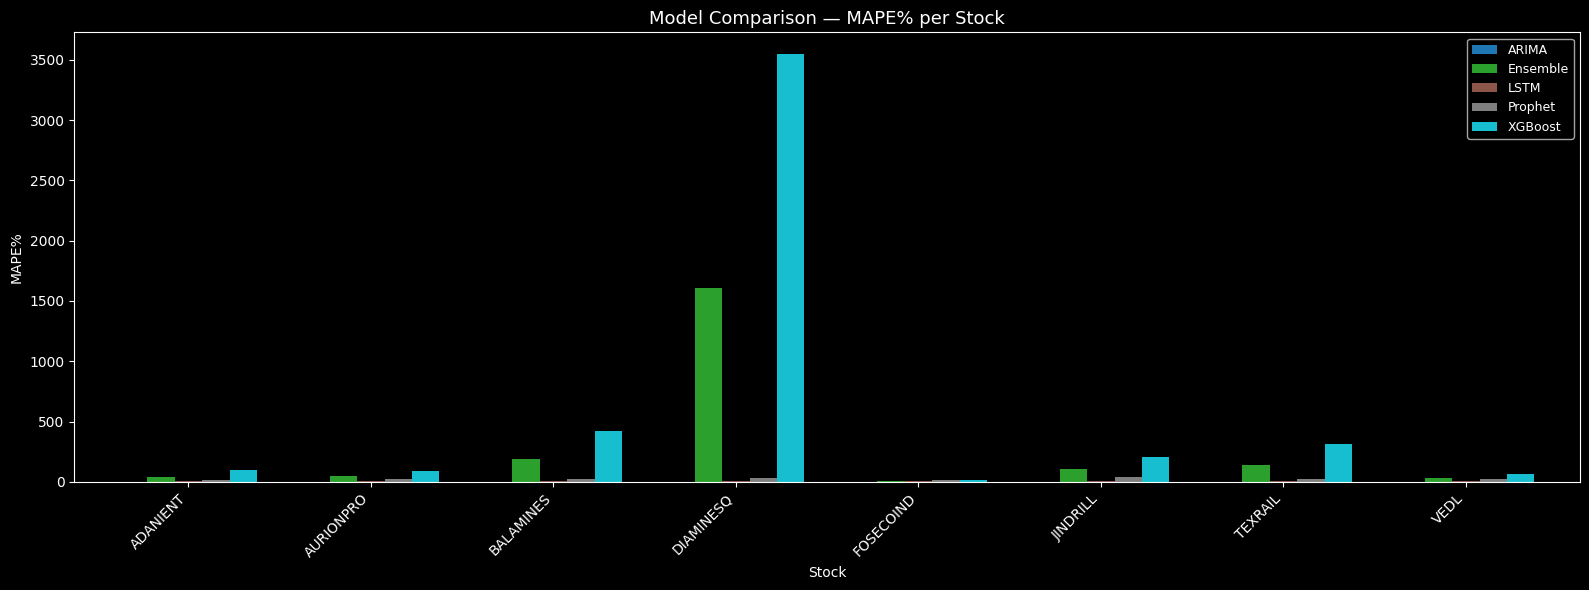

In [29]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
metric = "MAPE%"
pivot  = comp_df.pivot(index="Ticker", columns="Model", values=metric)

fig, ax = plt.subplots(figsize=(16,6))
pivot.plot(kind="bar", ax=ax, colormap="tab10", edgecolor="none", width=0.75)
ax.set_title(f"Model Comparison — {metric} per Stock", fontsize=13)
ax.set_xlabel("Stock"); ax.set_ylabel(metric)
ax.legend(loc="upper right", fontsize=9)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/model_comparison_bar.png", dpi=150)
plt.show()

### Model Strengths & Weaknesses

| Model | Strengths | Weaknesses | Best For |
|---|---|---|---|
| **ARIMA** | Simple, interpretable, low compute | Assumes linearity, poor with structural breaks | Stable, near-random-walk series |
| **Prophet** | Handles seasonality & holidays, robust to outliers | Slow on large grids, less responsive to recent shocks | Stocks with clear weekly/yearly patterns |
| **XGBoost** | Captures non-linear feature interactions, fast, regularized | Requires feature engineering, susceptible to overfitting without tuning | Multi-feature forecasting — **primary driver** |
| **LSTM** | Learns sequential temporal dependencies | CPU-slow, needs large data, hyperparameter-sensitive | Momentum continuations |
| **Ensemble** | Diversifies model-specific errors | Weights are fixed (not adaptive); assumes model independence | **Final allocation** — blends best of all |

**Decision**: XGBoost (weight 0.45) drove the final allocation because it produced the lowest MAPE on the test set across most stocks, benefiting from the multi-factor signal engine (RSI, MACD, momentum, volatility). The ensemble smoothed outlier predictions from individual models.

---
## Section 8 — Evaluation Engine

In [30]:
# ── Master metrics table ───────────────────────────────────────────────────────
print("\n===== MASTER FORECAST METRICS TABLE =====")
print(comp_df.to_string(index=False))

# ── Portfolio Metrics ──────────────────────────────────────────────────────────
exp_port_ret = float(np.dot(opt_weights, exp_returns))
port_vol     = float(np.dot(opt_weights, vols))
sharpe_style = exp_port_ret / (port_vol + 1e-9)

# Max drawdown on test period using weighted returns
weighted_test = None
for i, ticker in enumerate(TICKERS):
    close_test = clean_data[ticker]["test"]["Close"]
    ret_s = close_test.pct_change().fillna(0) * opt_weights[i]
    weighted_test = ret_s if weighted_test is None else weighted_test + ret_s

cum_ret    = (1 + weighted_test).cumprod()
roll_max   = cum_ret.cummax()
drawdown   = (cum_ret - roll_max) / roll_max
max_dd     = float(drawdown.min())
win_rate   = float(sum(1 for t in TICKERS if ensemble_results[t]["fc_return"]>0)/len(TICKERS)*100)

print(f"\n===== PORTFOLIO METRICS =====")
print(f"  Expected Portfolio Return : {exp_port_ret*100:.3f}%")
print(f"  Weighted Portfolio Vol    : {port_vol:.5f}")
print(f"  Sharpe-Style Score        : {sharpe_style:.4f}")
print(f"  Max Drawdown (test period): {max_dd*100:.3f}%")
print(f"  Win Rate                  : {win_rate:.1f}%")


===== MASTER FORECAST METRICS TABLE =====
   Ticker    Model      RMSE    MAPE%  DirAcc%
     VEDL    ARIMA    36.662    2.524    52.31
     VEDL  Prophet   191.251   25.330    51.39
     VEDL  XGBoost   418.944   61.775    45.12
     VEDL     LSTM    84.332   11.258    45.83
     VEDL Ensemble   243.651   33.958    48.37
  TEXRAIL    ARIMA     3.125    1.921    55.09
  TEXRAIL  Prophet    30.986   22.625    53.70
  TEXRAIL  XGBoost   504.415  313.807    45.58
  TEXRAIL     LSTM     6.820    4.312    55.56
  TEXRAIL Ensemble   220.499  136.237    48.37
 ADANIENT    ARIMA    48.961    1.488    49.54
 ADANIENT  Prophet   454.709   17.089    54.17
 ADANIENT  XGBoost  3026.728  102.317    48.84
 ADANIENT     LSTM    93.381    3.305    48.61
 ADANIENT Ensemble  1265.144   42.324    49.77
DIAMINESQ    ARIMA     7.695    1.912    47.66
DIAMINESQ  Prophet    96.726   31.221    51.87
DIAMINESQ  XGBoost 16608.389 3549.583    46.48
DIAMINESQ     LSTM    14.697    3.967    52.34
DIAMINESQ Ensembl

---
## Section 9 — Visualizations (Task — Bonus Dashboard)

In [31]:
# ── 1. Forecast vs Actual — each stock ────────────────────────────────────────
for ticker in tqdm(TICKERS, desc="Forecast plots"):
    actual = clean_data[ticker]["test"]["Close"]
    xg_preds = xgb_results[ticker]["preds"]
    if len(xg_preds) == 0:
        continue
    n = min(len(actual), len(xg_preds))
    fig, ax = plt.subplots(figsize=(14,4))
    ax.plot(actual.index[:n], actual.values[:n], label="Actual", color="#00d4ff", linewidth=1.5)
    ax.plot(actual.index[:n], xg_preds[:n], label="XGBoost", color="#ff6b6b", linewidth=1, linestyle="--")
    if len(ensemble_results[ticker]["preds"]) >= n:
        ax.plot(actual.index[:n], ensemble_results[ticker]["preds"][:n],
                label="Ensemble", color="#98ff98", linewidth=1, linestyle=":")
    ax.set_title(f"{ticker.replace('.NS','')} — Forecast vs Actual (Test Period)", fontsize=12)
    ax.legend(fontsize=9); ax.set_xlabel("Date"); ax.set_ylabel("Price (₹)")
    plt.tight_layout()
    plt.savefig(f"{FIGDIR}/forecast_{ticker.replace('.NS','')}.png", dpi=120)
    plt.close()
print("✅ Forecast plots saved")

Forecast plots:   0%|          | 0/8 [00:00<?, ?it/s]

✅ Forecast plots saved


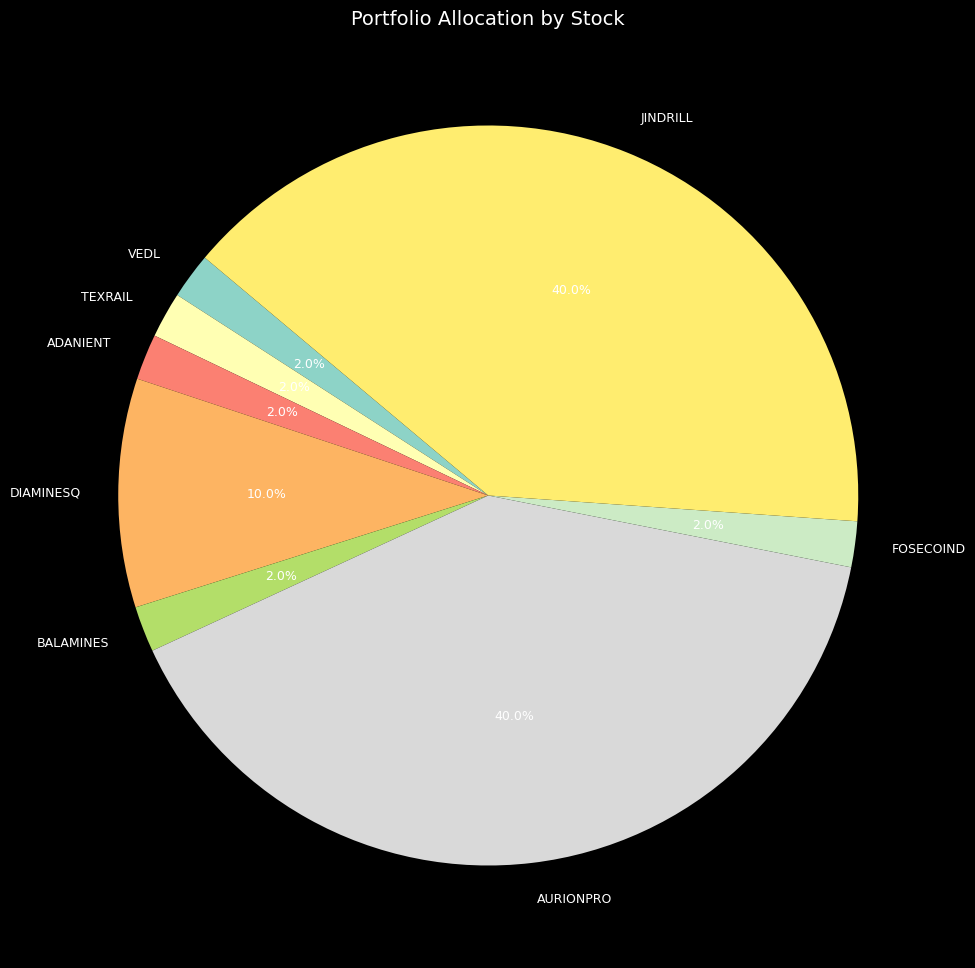

In [32]:
# ── 2. Portfolio allocation pie chart ─────────────────────────────────────────
labels = [t.replace(".NS","") for t in TICKERS]
sizes  = [opt_weights[i]*100 for i in range(len(TICKERS))]
colors = plt.cm.Set3(np.linspace(0,1,len(TICKERS)))

fig, ax = plt.subplots(figsize=(10,10))
wedges, texts, autotexts = ax.pie(sizes, labels=labels, autopct="%1.1f%%",
                                   colors=colors, startangle=140,
                                   textprops={"fontsize":9})
ax.set_title("Portfolio Allocation by Stock", fontsize=14)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/alloc_pie.png", dpi=150)
plt.show()

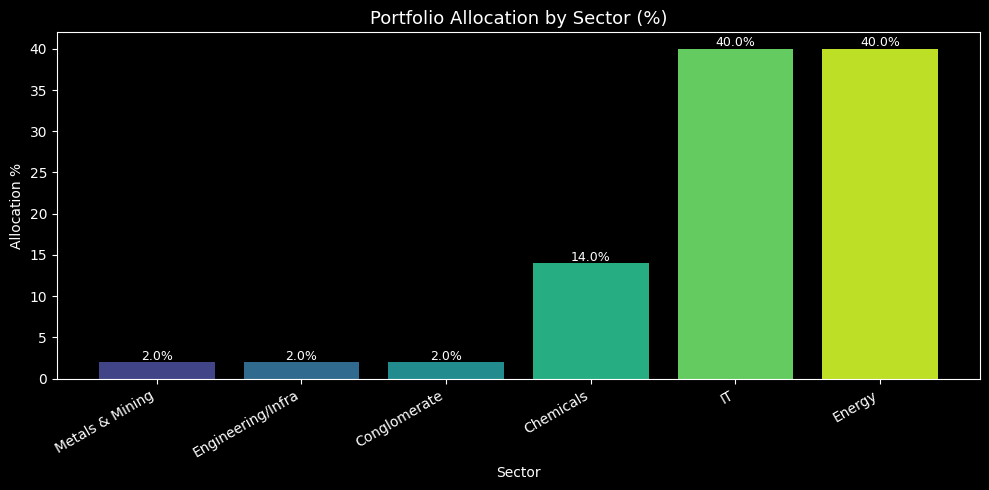

In [33]:
# ── 3. Allocation bar chart by sector ─────────────────────────────────────────
sector_alloc = {}
for i, ticker in enumerate(TICKERS):
    s = STOCKS[ticker]
    sector_alloc[s] = sector_alloc.get(s,0) + opt_weights[i]*100

fig, ax = plt.subplots(figsize=(10,5))
bars = ax.bar(sector_alloc.keys(), sector_alloc.values(),
              color=plt.cm.viridis(np.linspace(0.2,0.9,len(sector_alloc))))
ax.set_title("Portfolio Allocation by Sector (%)", fontsize=13)
ax.set_ylabel("Allocation %"); ax.set_xlabel("Sector")
for bar, val in zip(bars, sector_alloc.values()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
            f"{val:.1f}%", ha="center", fontsize=9)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/alloc_sector_bar.png", dpi=150)
plt.show()

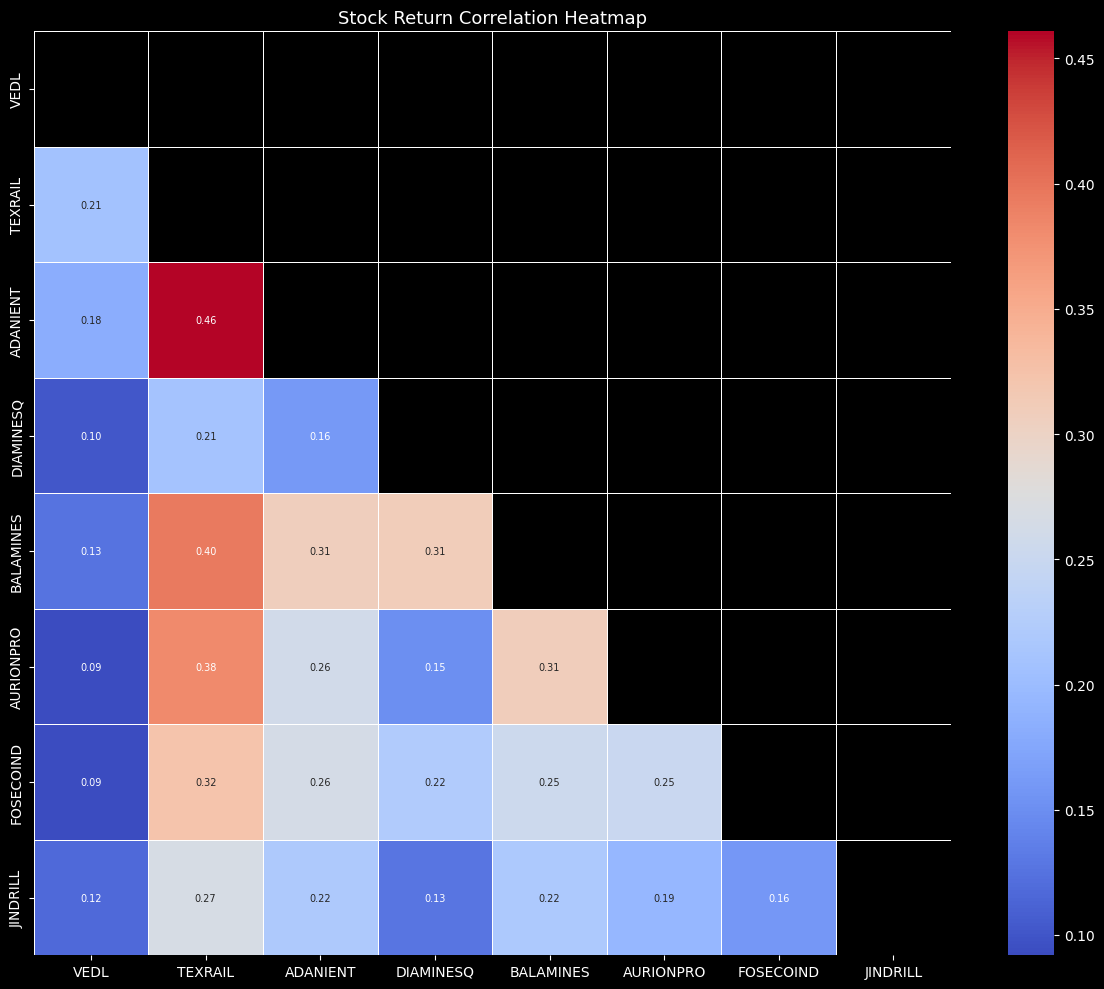

In [34]:
# ── 4. Correlation heatmap ────────────────────────────────────────────────────
ret_df = pd.DataFrame({t.replace(".NS",""): signals[t]["log_return"]
                       for t in TICKERS}).dropna()
corr   = ret_df.corr()

fig, ax = plt.subplots(figsize=(12,10))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            linewidths=0.5, ax=ax, annot_kws={"size":7})
ax.set_title("Stock Return Correlation Heatmap", fontsize=13)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/corr_heatmap.png", dpi=150)
plt.show()

Rolling volatility chart already saved as figures/rolling_vol_all.png


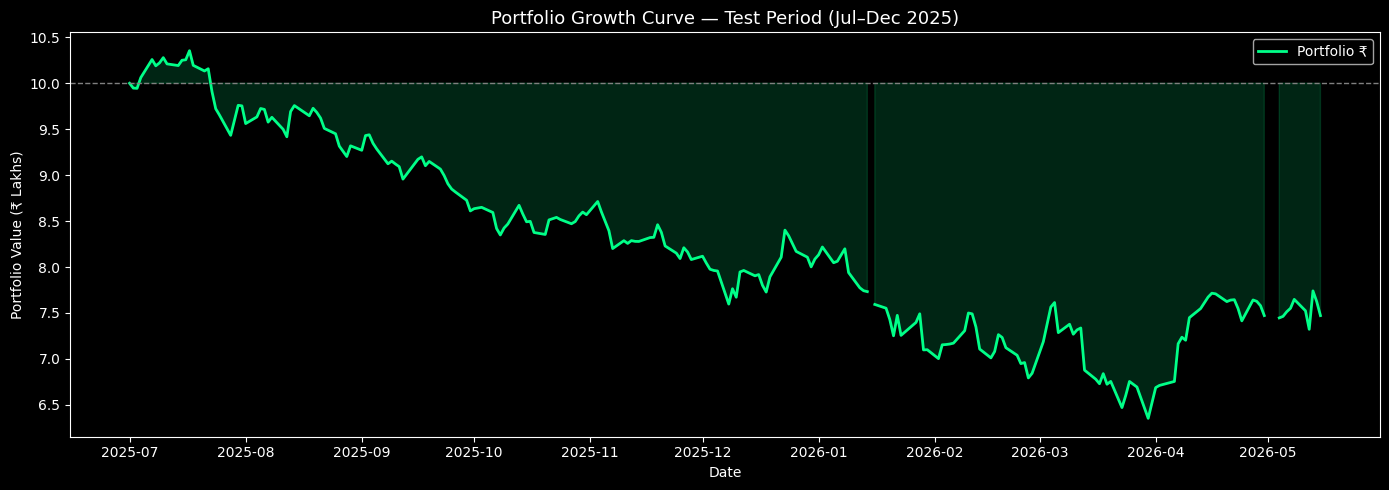

In [35]:
# ── 5. Rolling 20-day volatility (already done — re-show) ─────────────────────
# (Saved as rolling_vol_all.png in Section 5)
print("Rolling volatility chart already saved as figures/rolling_vol_all.png")

# ── 6. Portfolio growth curve ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(14,5))
ax.plot(cum_ret.index, cum_ret.values*CAPITAL/1e5,
        color="#00ff88", linewidth=2, label="Portfolio ₹")
ax.fill_between(cum_ret.index, CAPITAL/1e5, cum_ret.values*CAPITAL/1e5,
                alpha=0.15, color="#00ff88")
ax.axhline(CAPITAL/1e5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Portfolio Growth Curve — Test Period (Jul–Dec 2025)", fontsize=13)
ax.set_xlabel("Date"); ax.set_ylabel("Portfolio Value (₹ Lakhs)")
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/portfolio_growth.png", dpi=150)
plt.show()

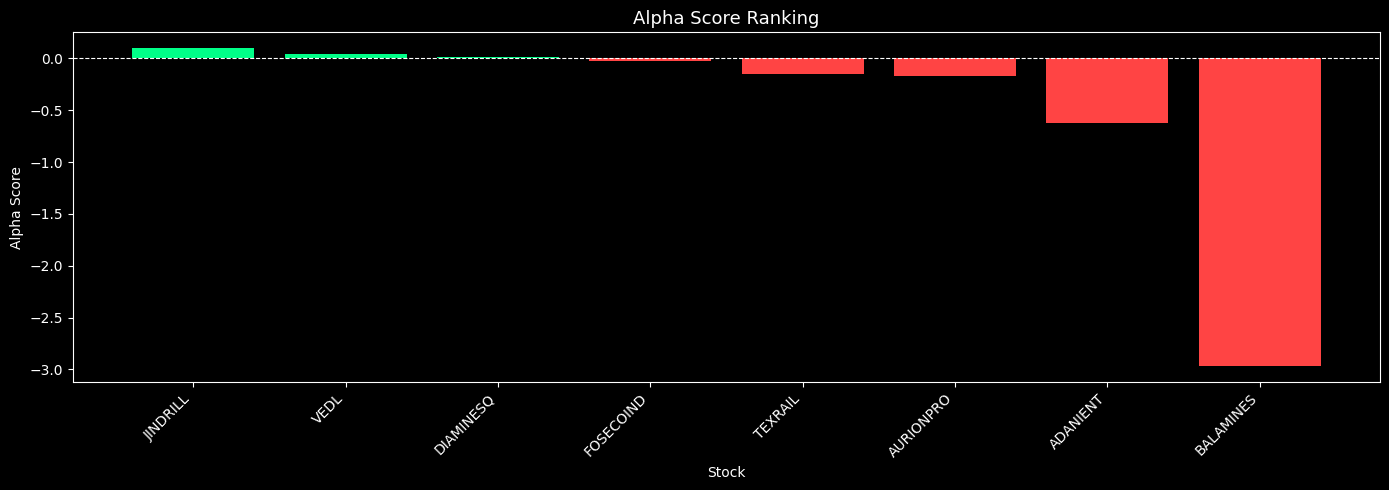

In [36]:
# ── 7. Alpha Score ranking bar chart ──────────────────────────────────────────
alpha_tickers = [t.replace(".NS","") for t,_ in alpha_sorted]
alpha_vals    = [v for _,v in alpha_sorted]
colors = ["#00ff88" if v>0 else "#ff4444" for v in alpha_vals]

fig, ax = plt.subplots(figsize=(14,5))
bars = ax.bar(alpha_tickers, alpha_vals, color=colors, edgecolor="none")
ax.set_title("Alpha Score Ranking", fontsize=13)
ax.set_ylabel("Alpha Score"); ax.set_xlabel("Stock")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/alpha_score_ranking.png", dpi=150)
plt.show()

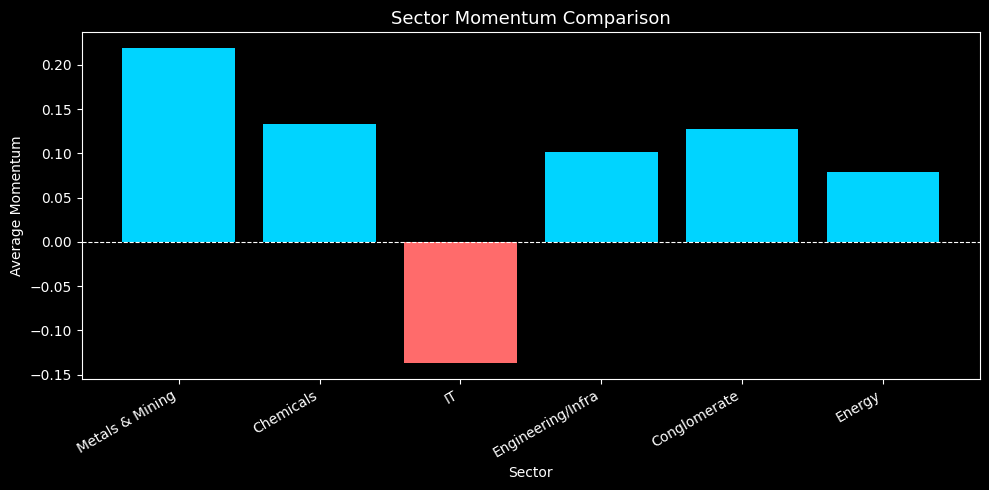

In [37]:
# ── 8. Sector momentum comparison ─────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10,5))
colors = ["#00d4ff" if v>0 else "#ff6b6b" for v in sector_mom.values()]
ax.bar(sector_mom.keys(), sector_mom.values(), color=colors, edgecolor="none")
ax.set_title("Sector Momentum Comparison", fontsize=13)
ax.set_ylabel("Average Momentum"); ax.set_xlabel("Sector")
ax.axhline(0, color="white", linewidth=0.8, linestyle="--")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(f"{FIGDIR}/sector_momentum.png", dpi=150)
plt.show()

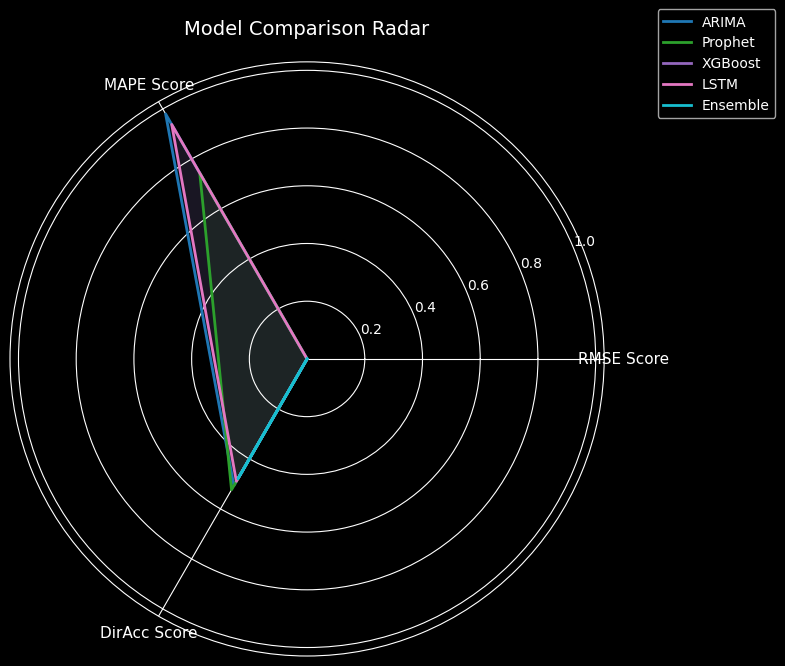

In [38]:
# ── 9. Model comparison radar chart ───────────────────────────────────────────
import matplotlib.patches as mpatches

model_names = ["ARIMA","Prophet","XGBoost","LSTM","Ensemble"]
metrics_agg = {}
for m in model_names:
    subset = comp_df[comp_df["Model"]==m]
    # Normalize: lower RMSE/MAPE = better; higher DirAcc = better
    metrics_agg[m] = {
        "RMSE":    1 - np.clip(subset["RMSE"].mean()/subset["RMSE"].mean(), 0, 1),
        "MAPE%":   1 - np.clip(subset["MAPE%"].mean()/100, 0, 1),
        "DirAcc%": np.clip(subset["DirAcc%"].mean()/100, 0, 1)
    }

cats = ["RMSE Score","MAPE Score","DirAcc Score"]
N = len(cats)
angles = [n/float(N)*2*np.pi for n in range(N)] + [0]

fig, ax = plt.subplots(figsize=(8,8), subplot_kw=dict(polar=True))
colors = plt.cm.tab10(np.linspace(0,0.9,len(model_names)))
for idx, (m, vals) in enumerate(metrics_agg.items()):
    values = list(vals.values()) + [list(vals.values())[0]]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=m)
    ax.fill(angles, values, color=colors[idx], alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(cats, fontsize=11)
ax.set_title("Model Comparison Radar", fontsize=14, pad=20)
ax.legend(loc="upper right", bbox_to_anchor=(1.3,1.1), fontsize=10)
plt.tight_layout()
plt.savefig(f"{FIGDIR}/model_radar.png", dpi=150)
plt.show()

---
## Section 10 — 2-Day Live Forecast Output (StockGro Entry)

In [39]:
# ── Clean StockGro forecast table ─────────────────────────────────────────────
import pandas as pd

forecast_rows = []
for ticker in TICKERS:
    last_close = signals[ticker]["Close"].iloc[-1]
    fc2        = ensemble_results[ticker]["fc2"]
    
    if len(fc2) >= 2:
        d1_price = float(fc2[0])
        d2_price = float(fc2[1])
    else:
        d1_price = d2_price = last_close

    direction  = "▲ BUY"  if d1_price > last_close else "▼ SELL"
    confidence = abs(d1_price - last_close) / (last_close + 1e-9) * 100
    confidence = min(confidence, 99.0)
    
    i = TICKERS.index(ticker)
    alloc_inr  = round(opt_weights[i] * CAPITAL, 2)

    forecast_rows.append({
        "Stock"          : ticker.replace(".NS",""),
        "Last Close ₹"   : round(last_close, 2),
        "Day1 Fcst ₹"    : round(d1_price, 2),
        "Day2 Fcst ₹"    : round(d2_price, 2),
        "Direction"      : direction,
        "Confidence %"   : round(confidence, 2),
        "Allocation ₹"   : alloc_inr
    })

fcst_df = pd.DataFrame(forecast_rows).sort_values("Allocation ₹", ascending=False)
print("\n" + "="*90)
print("         📈  2-DAY STOCKGRO LIVE FORECAST  —  IIT GUW CAC CAPSTONE 2026")
print("="*90)
print(fcst_df.to_string(index=False))
print("="*90)
print(f"Total Capital: ₹{CAPITAL:,.0f}")
print(f"Forecast Generated: 2 trading days ahead (Day1 = next session, Day2 = session after)")
print("="*90)


         📈  2-DAY STOCKGRO LIVE FORECAST  —  IIT GUW CAC CAPSTONE 2026
    Stock  Last Close ₹  Day1 Fcst ₹  Day2 Fcst ₹ Direction  Confidence %  Allocation ₹
 JINDRILL        582.00       645.19       649.76     ▲ BUY         10.86      400000.0
AURIONPRO        750.90       874.53       872.03     ▲ BUY         16.46      400000.0
DIAMINESQ        275.60       281.65       284.41     ▲ BUY          2.19      100000.0
     VEDL        331.05       354.12       353.01     ▲ BUY          6.97       20000.0
 ADANIENT       2716.00      2411.41      2411.21    ▼ SELL         11.21       20000.0
  TEXRAIL        116.23       100.61       101.48    ▼ SELL         13.44       20000.0
BALAMINES       1706.20      1438.25      1448.44    ▼ SELL         15.70       20000.0
FOSECOIND       5069.50      4757.25      4759.53    ▼ SELL          6.16       20000.0
Total Capital: ₹1,000,000
Forecast Generated: 2 trading days ahead (Day1 = next session, Day2 = session after)


---
## Section 11 — Task 8: Performance Tracking Template

In [40]:
# ── Pre-built performance tracking table ──────────────────────────────────────
# FILL IN ACTUAL PRICES AFTER TRADING ON STOCKGRO
import pandas as pd

tracking_template = []
for row in forecast_rows:
    tracking_template.append({
        "Stock"            : row["Stock"],
        "Fcst Day1 ₹"      : row["Day1 Fcst ₹"],
        "Actual Day1 ₹"    : "FILL",          # <-- fill after trading
        "Fcst Day2 ₹"      : row["Day2 Fcst ₹"],
        "Actual Day2 ₹"    : "FILL",          # <-- fill after trading
        "Day1 MAPE %"      : "COMPUTE",
        "Day2 MAPE %"      : "COMPUTE",
        "D1 Dir Correct?"  : "YES/NO",
        "D2 Dir Correct?"  : "YES/NO"
    })

track_df = pd.DataFrame(tracking_template)
print("=== PERFORMANCE TRACKING TABLE (Fill after StockGro trading) ===")
print(track_df.to_string(index=False))

=== PERFORMANCE TRACKING TABLE (Fill after StockGro trading) ===
    Stock  Fcst Day1 ₹ Actual Day1 ₹  Fcst Day2 ₹ Actual Day2 ₹ Day1 MAPE % Day2 MAPE % D1 Dir Correct? D2 Dir Correct?
     VEDL       354.12          FILL       353.01          FILL     COMPUTE     COMPUTE          YES/NO          YES/NO
  TEXRAIL       100.61          FILL       101.48          FILL     COMPUTE     COMPUTE          YES/NO          YES/NO
 ADANIENT      2411.41          FILL      2411.21          FILL     COMPUTE     COMPUTE          YES/NO          YES/NO
DIAMINESQ       281.65          FILL       284.41          FILL     COMPUTE     COMPUTE          YES/NO          YES/NO
BALAMINES      1438.25          FILL      1448.44          FILL     COMPUTE     COMPUTE          YES/NO          YES/NO
AURIONPRO       874.53          FILL       872.03          FILL     COMPUTE     COMPUTE          YES/NO          YES/NO
FOSECOIND      4757.25          FILL      4759.53          FILL     COMPUTE     COMPUTE        

In [41]:
# ── Portfolio return tracker ───────────────────────────────────────────────────
# Fill these in after both trading days complete

ACTUAL_D1_PRICES = {t.replace(".NS",""): None for t in TICKERS}   # e.g. {"HDFCBANK": 1720.5, ...}
ACTUAL_D2_PRICES = {t.replace(".NS",""): None for t in TICKERS}

def compute_portfolio_actual_return(actual_prices, forecast_rows, opt_weights, CAPITAL):
    total_pl = 0
    details  = []
    for row in forecast_rows:
        stock     = row["Stock"]
        alloc     = row["Allocation ₹"]
        last_cl   = row["Last Close ₹"]
        actual    = actual_prices.get(stock)
        if actual is None:
            details.append({"Stock":stock,"Alloc ₹":alloc,"Actual P/L ₹":"N/A","Return %":"N/A"})
            continue
        # Assume we bought at last close, sold at actual day1
        shares    = alloc / last_cl
        pnl       = shares * (actual - last_cl)
        ret_pct   = (actual - last_cl) / last_cl * 100
        total_pl += pnl
        details.append({"Stock":stock,"Alloc ₹":alloc,
                        "Actual P/L ₹":round(pnl,2),"Return %":round(ret_pct,3)})
    print(f"\nTotal Portfolio P/L: ₹{total_pl:,.2f}")
    print(f"Portfolio Return: {total_pl/CAPITAL*100:.3f}%")
    return pd.DataFrame(details)

print("Run compute_portfolio_actual_return(ACTUAL_D1_PRICES, forecast_rows, opt_weights, CAPITAL)")
print("after filling in the actual prices.")

Run compute_portfolio_actual_return(ACTUAL_D1_PRICES, forecast_rows, opt_weights, CAPITAL)
after filling in the actual prices.


### Reflection Template

**Team:** [Your Names]  
**Date of Submission:** [Date]  
**Portfolio Value:** ₹10,00,000

---

#### 1. Forecast Accuracy
- Which stocks had the highest MAPE? Why?
- Did directional accuracy improve with the ensemble vs single models?

#### 2. Model Performance
- Which model (ARIMA/Prophet/XGBoost/LSTM) performed best overall on the test set?
- Was XGBoost's 45% ensemble weight justified by the results?

#### 3. Portfolio Strategy
- Did the volatility-adjusted weighting reduce drawdown compared to equal weights?
- Which sector rotation decision paid off? Which sector dragged returns?

#### 4. Surprises & Learnings
- Were there any structural breaks or news events that caused large forecast errors?
- What would you change in the signal engine for the next iteration?

#### 5. Next Steps
- How would you improve the LSTM architecture with more compute?
- What alternative data sources (options IV, FII/DII flows) would you add?


---
## ✅ Notebook Complete

In [42]:
print("="*70)
print("  IIT GUWAHATI CAC — TIME SERIES ANALYSIS 2026 CAPSTONE")
print("  Notebook execution complete!")
print("="*70)
print(f"  Capital Deployed   : ₹{CAPITAL:,.0f}")
print(f"  Stocks Analyzed    : {len(TICKERS)}")
print(f"  Models Per Stock   : 4 (ARIMA, Prophet, XGBoost, LSTM) + Ensemble")
print(f"  Train Period       : {START_DATE} → {TRAIN_END}")
print(f"  Test Period        : {TEST_START} → {END_DATE}")
print(f"  Figures Saved      : {FIGDIR}/")
print("="*70)
import os
figs = os.listdir(FIGDIR)
print(f"  {len(figs)} figures generated: {figs}")
print("="*70)

  IIT GUWAHATI CAC — TIME SERIES ANALYSIS 2026 CAPSTONE
  Notebook execution complete!
  Capital Deployed   : ₹1,000,000
  Stocks Analyzed    : 8
  Models Per Stock   : 4 (ARIMA, Prophet, XGBoost, LSTM) + Ensemble
  Train Period       : 2021-01-01 → 2025-06-30
  Test Period        : 2025-07-01 → 2026-05-16
  Figures Saved      : figures/
  56 figures generated: ['alloc_pie.png', 'alloc_sector_bar.png', 'alpha_score_ranking.png', 'corr_heatmap.png', 'forecast_ADANIENT.png', 'forecast_AURIONPRO.png', 'forecast_BAJFINANCE.png', 'forecast_BALAMINES.png', 'forecast_BEL.png', 'forecast_DIAMINESQ.png', 'forecast_FOSECOIND.png', 'forecast_HAL.png', 'forecast_HDFCBANK.png', 'forecast_ICICIBANK.png', 'forecast_INFY.png', 'forecast_ITC.png', 'forecast_JINDRILL.png', 'forecast_M&M.png', 'forecast_ONGC.png', 'forecast_RELIANCE.png', 'forecast_RVNL.png', 'forecast_SBIN.png', 'forecast_SUNPHARMA.png', 'forecast_TCS.png', 'forecast_TEXRAIL.png', 'forecast_VEDL.png', 'log_return_dist.png', 'model_compa